In [ ]:
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import snntorch as snn
from snntorch import utils
from snntorch import spikegen, surrogate
import snntorch.functional as SF
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# -------------- Parameters -----------------------
time_steps = 39512

class plot():
    def plotxy(
        series_list,
        index=None,
        title="",
        xlabel="time stamps",
        ylabel="",
        figsize=(14, 7),
        axhline=None,
        show_legend=True,
        disable_scietific_format = False,
    ):
        plt.figure(figsize=figsize), 
        
        for series  in series_list: 
            y_vals = np.asarray(series["y"])
            if index is not None:
                y_vals = y_vals[:index]
                
            plt.plot(
            y_vals,
            label=series.get("label"),
            color=series.get("color", "#0275D8"),
            linewidth=series.get("linewidth", 1.5),
            alpha=series.get("alpha", 1.0),
            linestyle=series.get("linestyle", "-"),)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if disable_scietific_format == True:
            plt.ticklabel_format(style="plain", useOffset=False, axis="both")
        if axhline is not None:
            plt.axhline(axhline, color="black", linestyle="--", alpha=0.5)

        if show_legend:
            plt.legend()
        plt.show()
        
        
        
    def plot_spikes(
        series_list,
        index=None,
        value = 1.0,
        title="",
        xlabel="time stamps",
        ylabel="Spikes",
        figsize=(14, 7),
        axhline=None,
        show_legend=True,
        disable_scietific_format=False,
        
    ):
        plt.figure(figsize=figsize), 
        
        for series in series_list:
            
            y_spikes = np.asarray(series["y"])
            if index is not None:
                y_spikes = y_spikes[:index]
            
            spike_point = np.atleast_1d(y_spikes)
            spike_point = np.where(y_spikes == value)[0]
            plt.vlines(
                spike_point,
                ymax=series.get("ymax", 0.5),
                ymin=series.get("ymin", 1.5),
                label=series.get("label"),
                color=series.get("color", "red"),
                linewidth=series.get("linewidth", 1.5),
                alpha=series.get("alpha", 1.0),
                linestyle=series.get("linestyle", "-"),
           )
            
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        
        if disable_scietific_format == True:
            plt.ticklabel_format(style="plain", useOffset=False, axis="both")
        if axhline is not None:
            plt.axhline(axhline, color="black", linestyle="--", alpha=0.5)

        if show_legend:
            plt.legend()
        plt.show()
        

def test_accuracy(data_loader, net, num_steps, device, population_code=False, num_classes=False):
  with torch.no_grad():
    total = 0
    acc = 0
    net.eval()

    data_loader = iter(data_loader)
    for data, targets in data_loader:
      data = data.to(device)
      targets = targets.to(device)
      utils.reset(net)
      spk_rec, _ = net(data)

      if population_code:
        acc += SF.accuracy_rate(spk_rec.unsqueeze(0), targets, population_code=True, num_classes=10) * spk_rec.size(1)
      else:
        acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)

      total += spk_rec.size(1)

  return acc/total


        
plot_xy = plot.plotxy
plot_spike  = plot.plot_spikes



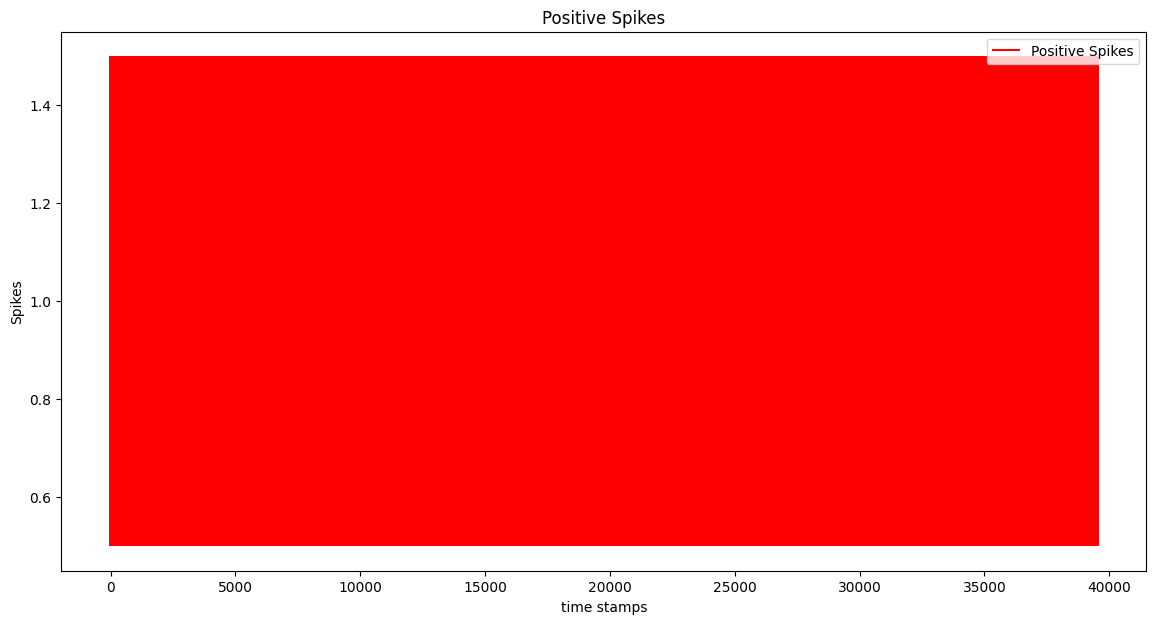

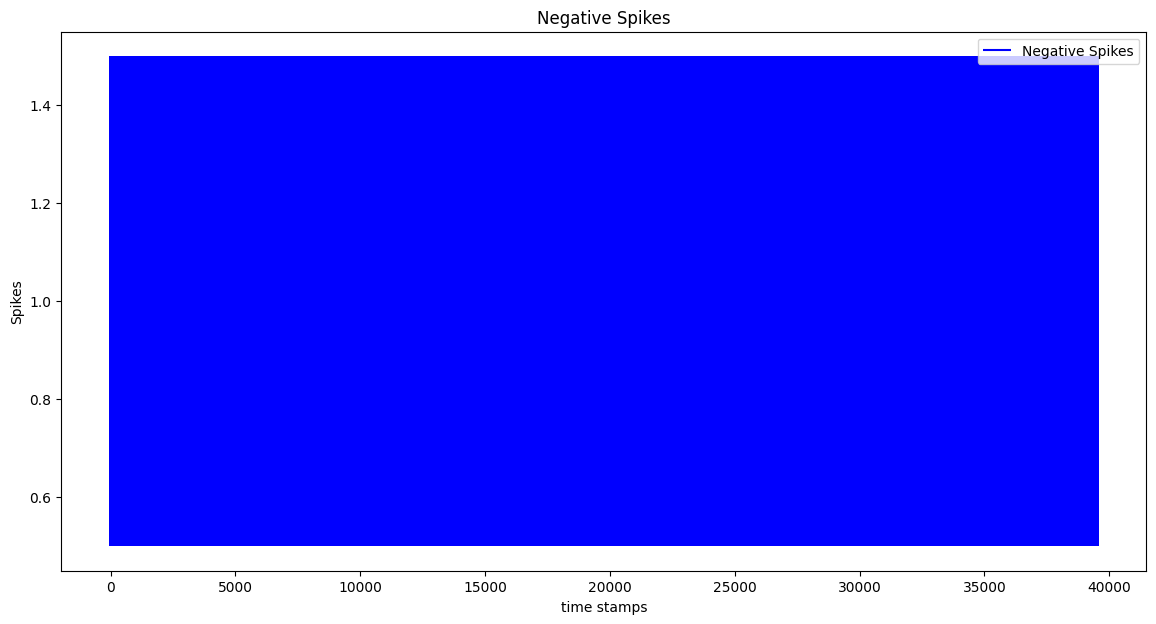

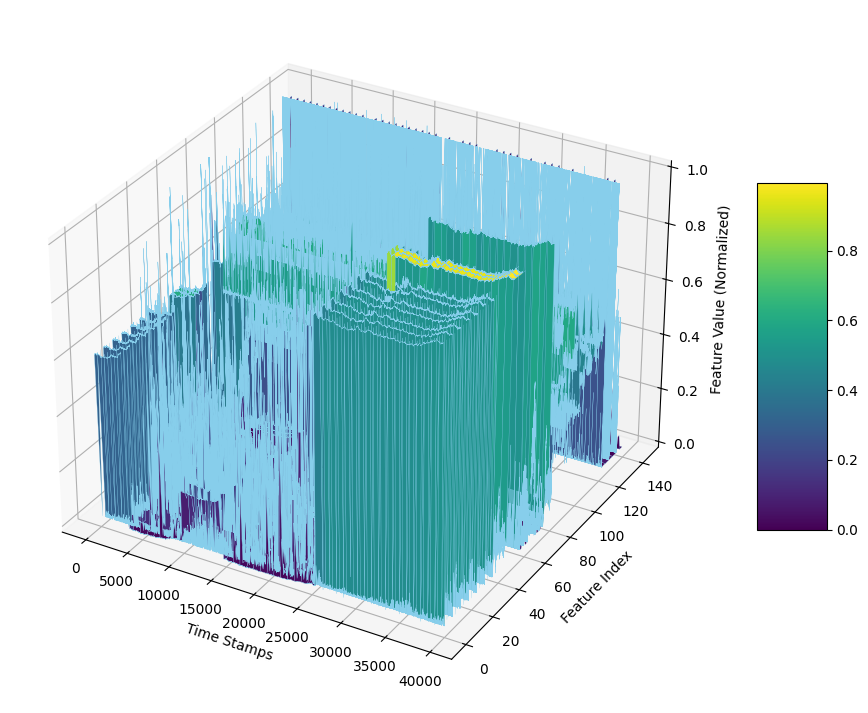

In [ ]:
### Setup the training Data
# -------------- Parameters -----------------------
time_steps = 39512
train_file = "data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_1.txt"

data = np.loadtxt(train_file)

ask_price = data[0, :]
bid_price = data[2, :]
mid_price = (ask_price + bid_price) / 2
features  = data[:144, :].T 
labels    = data[146, :].T - 1

plot_xy(
    series_list=[
        {"y": mid_price, "label": "Positive Spikes"},
    ],
    index=time_steps,
    title="Positive Spikes"
)


features_tensor = torch.from_numpy(features).float()
labels_tensor = torch.from_numpy(labels).float()


spike = spikegen.delta(features_tensor, threshold=0.01, padding=True, off_spike=True)
spikes_pos = torch.where(spike > 0, spike, torch.zeros_like(spike))
spikes_neg = torch.where(spike < 0, torch.abs(spike), torch.zeros_like(spike))

plot_spike(
    series_list=[
        {"y": spikes_pos, "label": "Positive Spikes"},
    ],
    index=time_steps,
    title="Positive Spikes"
)
plot_spike(
    series_list=[
        {"y": spikes_neg, "label": "Negative Spikes", "color": "blue"},
    ],
    index=time_steps,
    title="Negative Spikes"
)

Z = features_tensor[:time_steps, :].numpy()

X, Y = np.meshgrid(np.arange(time_steps), np.arange(144))
Z = Z.T

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="skyblue", linewidth=.2)
ax.set_xlabel('Time Stamps')
ax.set_ylabel("Feature Index")
ax.set_zlabel("Feature Value (Normalized)")
# ax.view_init(elev=0, azim=180)
fig.colorbar(surface, shrink=.5, aspect=5)

plt.show()

In [230]:
### Setup the Testing Data
test_file  = "data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_1.txt"

test_data = np.loadtxt(test_file)
features_test  = test_data[:144, :].T 
labels_test    = test_data[146, :].T - 1



features_tensor_test = torch.from_numpy(features_test).float()
labels_tensor_test = torch.from_numpy(labels_test).long()


spike_test = spikegen.delta(features_tensor_test, threshold=0.01, padding=True, off_spike=True)
spikes_pos_test = torch.where(spike_test > 0, spike_test, torch.zeros_like(spike_test))
spikes_neg_test = torch.where(spike_test < 0, torch.abs(spike_test), torch.zeros_like(spike_test))

 
test_inputs = torch.cat((spikes_pos_test, spikes_neg_test), dim=1)
test_dataset = TensorDataset(test_inputs, labels_tensor_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

inputs_train = torch.cat((spikes_pos, spikes_neg), dim=1)

dataset = TensorDataset(inputs_train, labels_tensor)

batch_size = 16
# shuffle is set to false to keep the time-series sequence order (took me 3 days to debug ughhh)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

print(f"dataloader {len(train_loader)}")

dataloader 2470


In [ ]:
# Parameters of the network
num_inputs = 288
num_hidden = 128
num_outputs = 3
beta = .9
num_seps = 25

spike_grad = surrogate.fast_sigmoid(slope=25)

class HFT_Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1  = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(threshold=.5,  beta=beta, spike_grad=spike_grad)
        self.fc2  = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(threshold=.5, beta=beta, spike_grad=spike_grad)
        
    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk2_rec = []
        mem2_rec = []
        
        for step in range(x.shape[0]):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
            
        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = HFT_Net().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=2e-4, betas=(0.9, 0.999))
class_weights = torch.tensor([2.0, 0.5, 2.0]).to(device)
loss_fn = SF.ce_rate_loss(weight=class_weights)

num_epochs = 25
loss_hist = []
spk_re = []
for epoch in range(num_epochs):
    net.train()
    
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device).long()
        
        data_seq = data.unsqueeze(1) 
        target_seq = targets[-1].unsqueeze(0)
        
        spk_rec, mem_rec = net(data_seq)
        
        loss_val = loss_fn(spk_rec, target_seq)
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        loss_hist.append(loss_val.item())
        
         
        if batch_idx % 50 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx} \tTraining Loss: {loss_val.item():.4f}")
            


NameError: name 'train_loader' is not defined

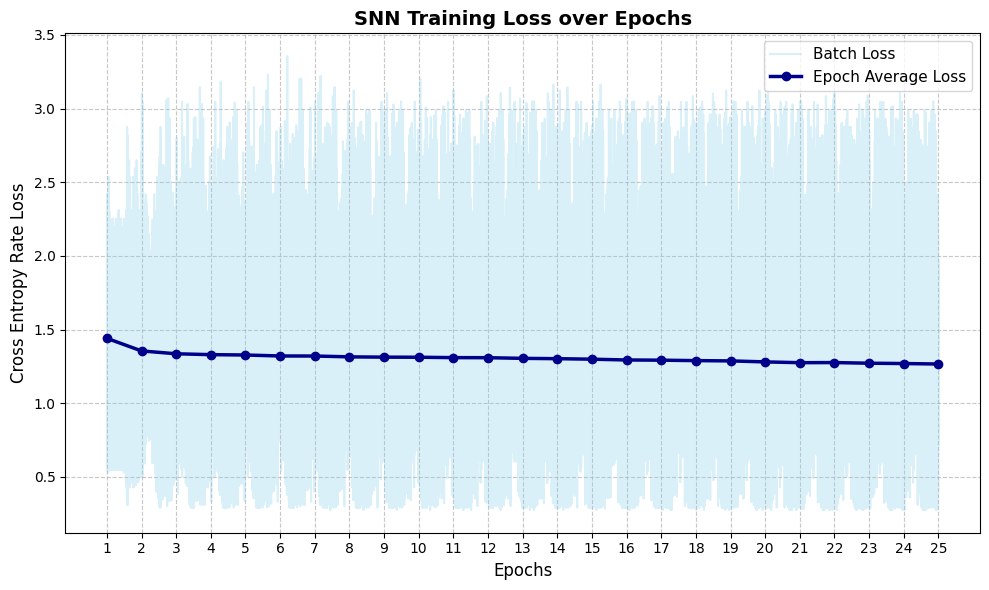

1.3082660411171585
1.3082660411171585
1.3082660411171585
[1.44107843 1.35548628 1.33607983 1.33021504 1.32780551 1.32114356
 1.32088122 1.31521759 1.31325328 1.31267965 1.30996414 1.30952797
 1.30504644 1.30286815 1.2994171  1.294102   1.29268858 1.28968631
 1.2877698  1.28100738 1.2757003  1.27647549 1.27206598 1.26994036
 1.26655066]
[1.35548628 1.33607983 1.33021504 1.32780551 1.32114356 1.32088122
 1.31521759 1.31325328 1.31267965 1.30996414 1.30952797 1.30504644
 1.30286815 1.2994171  1.294102   1.29268858 1.28968631 1.2877698
 1.28100738 1.2757003  1.27647549 1.27206598 1.26994036 1.26655066]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate how many batches were in a single epoch
batches_per_epoch = len(train_loader)
total_epochs = len(loss_hist) // batches_per_epoch

# 2. Reshape the flat loss list into a 2D array: (Epochs, Batches)
# and calculate the average loss per epoch
loss_array = np.array(loss_hist)[:total_epochs * batches_per_epoch].reshape(total_epochs, batches_per_epoch)

epoch_losses = loss_array.mean(axis=1)

# 3. Create the X-axis values (Epochs 1 to N)
epochs_x = np.arange(1, total_epochs + 1)
batches_x = np.linspace(1, total_epochs, len(loss_hist))

# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot the raw batch loss in the background (faded) to show the actual LOB volatility
plt.plot(batches_x, loss_hist, color='skyblue', alpha=0.3, label='Batch Loss')

# Plot the clean, averaged epoch loss on top
plt.plot(epochs_x, epoch_losses, color='darkblue', linewidth=2.5, marker='o', label='Epoch Average Loss')

# Formatting for a research paper
plt.title("SNN Training Loss over Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Cross Entropy Rate Loss", fontsize=12)
plt.xticks(epochs_x) # Force the X-axis to show whole numbers for epochs
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()

plt.show()


 